# Simulating Stock Price Using the Geometric Brownian Motion Model

We assume that the stock price $S$ follows Geometric Brownian Motion, with expected rate of return $\mu$ and volatility $\sigma$:

$$ dS = \mu S dt + \sigma S dz .$$

By Itô's Lemma, if $G$ is a function of $S$ and $t$, then the process followed by $G$ is given by

\begin{equation} dG = \left( \frac{\partial G}{\partial t} + \mu S \frac{\partial G}{\partial S} + \frac{1}{2} \frac{\partial^2 G}{\partial S^2} \sigma^2 S^2 \right)dt + \frac{\partial G}{\partial S} \sigma S dz. \tag{1} \end{equation}

Let $G = \ln S$. Then, $\frac{\partial G}{\partial S} = \frac{1}{S}$, $\frac{\partial^2 G}{\partial S^2} = - \frac{1}{S^2}$, and $\frac{\partial G}{\partial t} = 0$. Substituting this in $(1)$ gives

$$ dG = \left( \mu - \frac{1}{2} \sigma^2 \right)dt + \sigma dz .$$

Here, $\mu$ and $\sigma$ are constant. Comparing this with the generalized Wiener process $dx = adt + bdz$, we can see that the after time $T$, the change in the variable $G$ can be expressed as

$$ \ln S_T - \ln S_0 \sim \mathcal{N} \left( \left( \mu - \frac{\sigma^2}{2} \right) T, \sigma^2 T \right), $$

that is, 

$$ \ln S_T - \ln S_0 = \left( \mu - \frac{\sigma^2}{2} \right) T + \sigma \sqrt{T} Z ,$$

and so,

$$ S_T = S_0 \exp \left( \left( \mu - \frac{\sigma^2}{2} \right) T + \sigma \sqrt{T} Z \right).$$

Here, $S_0$ and $S_T$ are the prices of the stock at time $0$ and $T$, respectively.

In [1]:
import numpy as np
import numpy.random as npr
import matplotlib.pylab as plt

In [2]:
'''
Simulates the terminal price of a stock after time T

S0 : current stock price
mu : expected rate of return
sigma : volatility
T : time horizon (in years)
N : number of simulations

Returns : ndarray of shape (N,) containing N simulated prices
'''

def sim_terminal_gbm(S0, mu, sigma, T, N):
    S_T = S0 * np.exp((mu - 0.5 * sigma ** 2) * T + sigma * np.sqrt(T) * npr.randn(N))
    return S_T

For example:

In [3]:
S0 = 100
mu = 0.05
sigma = 0.25
T = 2.0
N = 10000

S = sim_terminal_gbm(S0, mu, sigma, T, N)

To obtain a histogram from the terminal prices:

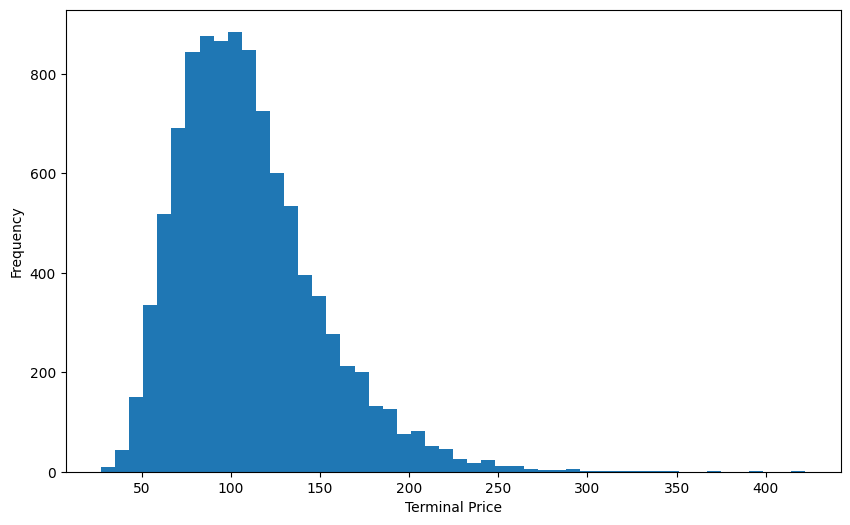

In [4]:
plt.figure(figsize=(10, 6))
plt.hist(S, bins=50)
plt.xlabel('Terminal Price')
plt.ylabel('Frequency')
plt.show()

To simulate the path instead of just the terminal price, we divide the total time horizon $T$ into $I$ intervals, each of length $\Delta t = \frac{T}{I}$. Let $S_0$ be the initial stock price and $S_i$ be the stock price after $i$ intervals, $1 \leq i \leq I$. Then,

$$ S_{i} = S_{i - 1} \exp \left( \left( \mu - \frac{1}{2}\sigma^2 \right) \Delta t + \sigma \sqrt{\Delta t} z \right), $$

where $1 \leq i \leq I$. 

In [11]:
'''
Simulates the path of the stock price

S0 : current stock price
mu : expected rate of return
sigma : volatility
T : time horizon (in years)
N : number of simulations
I : number of intervals

Returns : ndarray of shape (I + 1, N), with each column representing a simulated path
'''

def sim_path_gbm(S0, mu, sigma, T, N, I):
    dt = T / I
    paths = np.zeros((I + 1, N))
    paths[0] = S0

    for i in range(1, I + 1):
        paths[i] = paths[i - 1] * np.exp((mu - 0.5 * sigma ** 2) * dt + sigma * np.sqrt(dt) * npr.randn(N))

    return paths

For example:

In [6]:
S0 = 100
mu = 0.05
sigma = 0.25
T = 2.0
N = 10000
I = 50

paths = sim_path_gbm(S0, mu, sigma, T, N, I)

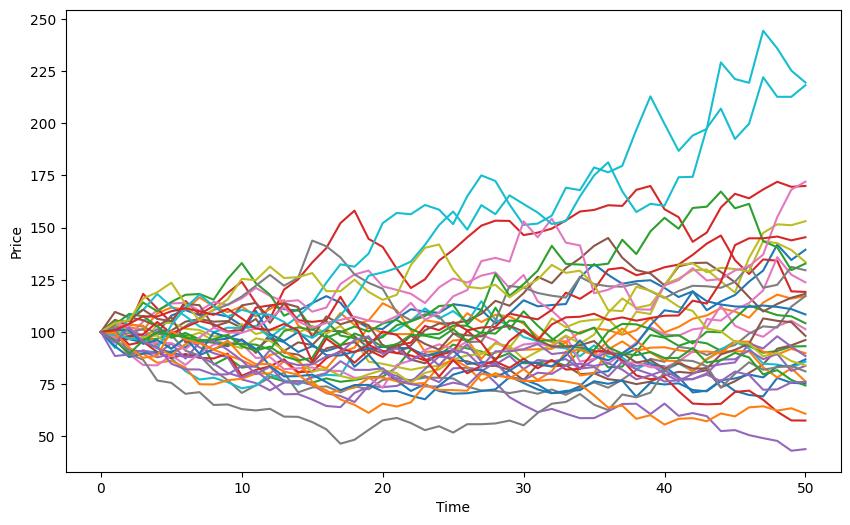

In [7]:
plt.figure(figsize=(10, 6))
plt.plot(paths[:, :35], lw=1.5) # plotting 35 of the 10,000 paths simulated
plt.xlabel('Time')
plt.ylabel('Price')
plt.show()

Histogram for the terminal prices obtained from the path simulations:

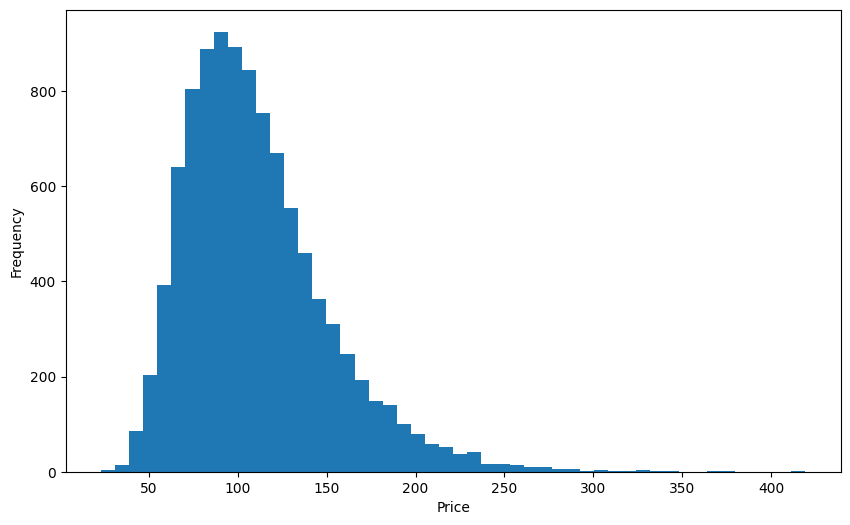

In [8]:
plt.figure(figsize=(10, 6))
plt.hist(paths[-1], bins=50)
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()